Implementation 'from scratch' https://www.baeldung.com/cs/bagging-boosting-stacking-ml-ensemble-models

## Ensemble Methods: Bagging, Boosting, and Stacking

### Bagging (Bootstrap Aggregating)
- Trains multiple **identical models** on different bootstrap samples  
- Models are trained **independently and in parallel**
- Final prediction is obtained by **averaging** (regression) or **majority voting** (classification)
- Mainly reduces **variance**
- Works well with **unstable models** (e.g., decision trees)
- Example: **Random Forest**

---

### Boosting
- Models are trained **sequentially**
- Each new model focuses on **errors made by previous models**
- Final prediction is a **weighted sum** of all models
- Mainly reduces **bias**
- Can be sensitive to noise
- Examples: **AdaBoost, Gradient Boosting, XGBoost, LightGBM, CatBoost**

---

### Stacking
- Combines **different types of models**
- Base models generate **predictions used as features**
- A **meta-model** learns how to combine these predictions
- Uses **k-fold cross-validation** to avoid data leakage
- Often achieves high performance but is **more complex**
- Common meta-models: **Linear / Logistic Regression**


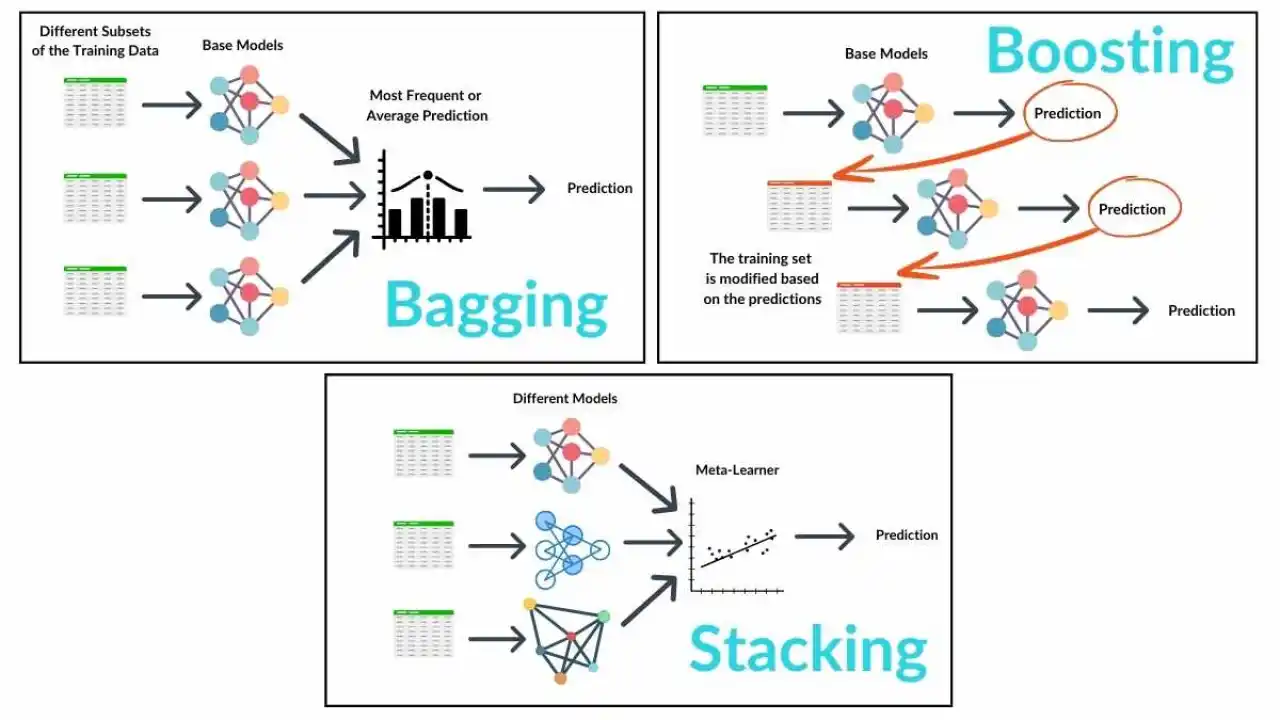

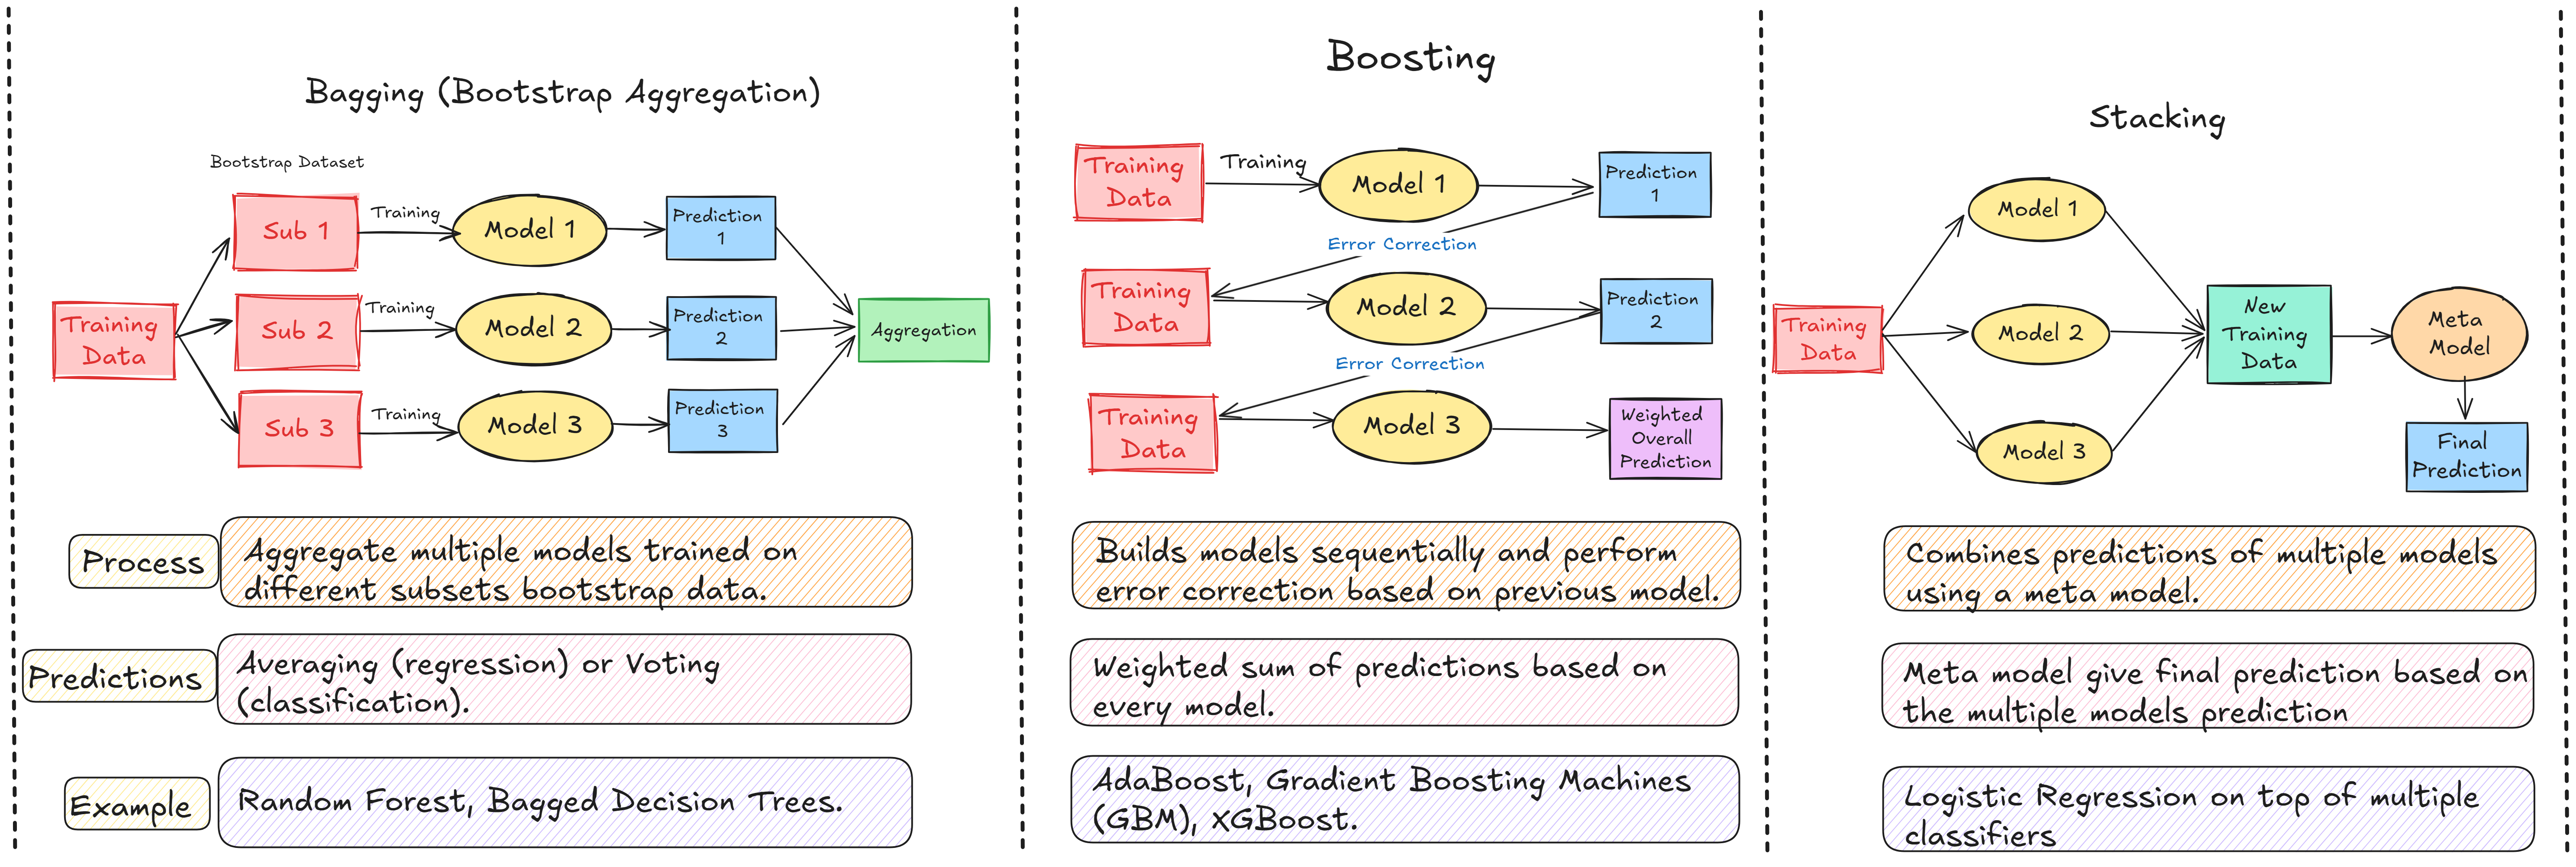

# Staking

https://www.geeksforgeeks.org/machine-learning/stacking-in-machine-learning/

https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.StackingClassifier.html

Stacking architecture is like a team of models working together in two layers to improve prediction accuracy

## Example: Stacking Classifier
**3 base models and 1 meta-model**

#### Step 1: Split data using K-fold cross-validation (K = 5) and train base models

The dataset is divided into five folds: Fold 1 | Fold 2 | Fold 3 | Fold 4 | Fold 5


- Train all base models on Folds 2–5  
- Keep Fold 1 as the validation (out-of-fold) set  

Repeat this procedure so that each fold is used once as the validation fold.

#### Step 2: Generate out-of-fold (OOF) predictions

- Base models generate predictions on the Fold 1  


#### Step 3: Train the meta-model

- Train the meta-model using:
  - Input features: predictions on Fold 1 from the three base models  
  - Target: true labels of Fold 1  



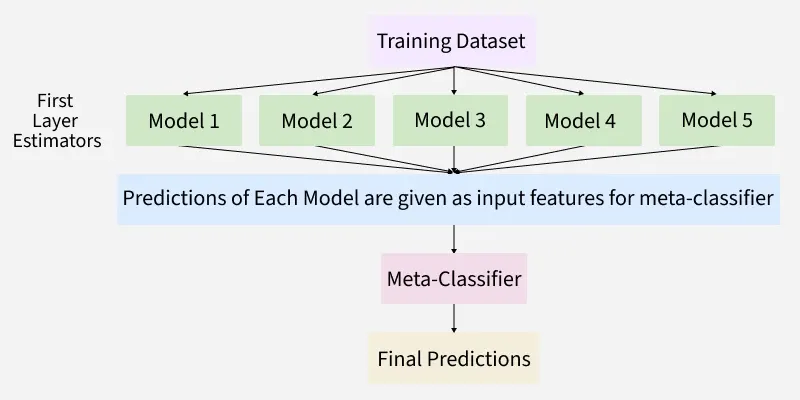

In [1]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier

In [2]:
X, y = make_classification(
    n_samples=5000,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


In [3]:
lr = LogisticRegression(max_iter=1000)
dt = DecisionTreeClassifier(
    max_depth=6,   
    min_samples_leaf=50,
    random_state=42
)


In [4]:
models = {
    "Logistic Regression": lr,
    "Decision Tree": dt
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"{name}: accuracy = {acc:.4f}")


Logistic Regression: accuracy = 0.8344
Decision Tree: accuracy = 0.8320


In [5]:
stacking = StackingClassifier(
    estimators=[
        ('lr', lr),
        ('dt', dt),
    ],
    final_estimator=LogisticRegression(),
    cv=5,
    n_jobs=-1
)

stacking.fit(X_train, y_train)

stack_preds = stacking.predict(X_test)
stack_acc = accuracy_score(y_test, stack_preds)

print(f"Stacking accuracy = {stack_acc:.4f}")


Stacking accuracy = 0.8496


# Bagging

Bagging (bootstrap aggregating) is an ensemble method that involves training multiple models independently on random subsets of the data, and aggregating their predictions through voting or averaging.

# Example: Bagging
**Ensemble of multiple base models trained on bootstrap samples**

#### Step 1: Create bootstrap samples

- From the original dataset, generate multiple **random samples with replacement**  
- Each sample has the same size as the original dataset, but some points may repeat and some may be missing

Original dataset:   1 2 3 4 5 6 7 8 9 10
Bootstrap sample 1: 2 5 1 3 3 3 8 9 1 4
Bootstrap sample 2: 1 6 3 5 5 7 8 9 10 4


#### Step 2: Train base models

- Train a base model on each bootstrap sample independently  
- Base models can be:
  - Decision Trees


#### Step 3: Make predictions

- For a new sample:
  - Each base model predicts independently  


#### Step 4: Combine predictions

- **Classification:** majority vote  
- **Regression:** average of predictions  


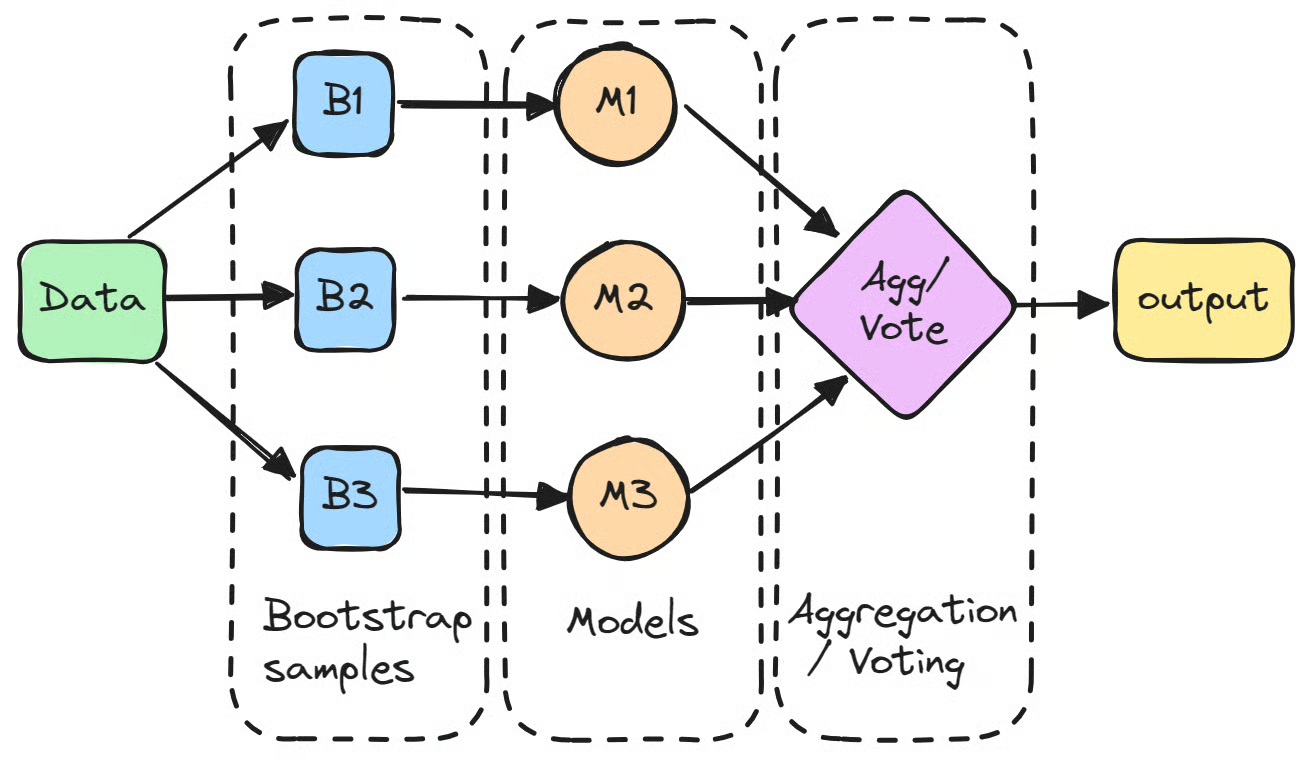

## Real Example with DecisionTree as base learner

In [16]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

In [17]:
# Create dataset
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25,
    random_state=42
)

In [18]:
# Define base learner
base_tree = DecisionTreeClassifier(max_depth=None, random_state=42)

# Define Bagging ensemble
bagging_model = BaggingClassifier(
    estimator=base_tree,   # base learner
    n_estimators=50,       # number of trees
    max_samples=0.8,       # each tree trained on 80% of samples (with replacement)
    max_features=1.0,      # use all features
    bootstrap=True,        # sampling with replacement
    random_state=42
)

# Train the model
bagging_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = bagging_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Bagging (Decision Tree)accuracy: {accuracy:.4f}")


Bagging (Decision Tree)accuracy: 0.8840


## Real Example with Logistic Regression as base learner

In [19]:
base_lr = LogisticRegression(max_iter=1000)

# Define Bagging ensemble
bagging_model = BaggingClassifier(
    estimator=base_lr,   # base learner
    n_estimators=20,     # number of models
    max_samples=0.8,     # each model trained on 80% of data
    bootstrap=True,
    n_jobs=-1,           # parallel training
    random_state=42
)

# rain the model
bagging_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = bagging_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Bagging (Logistic Regression) accuracy: {accuracy:.4f}")


Bagging (Logistic Regression) accuracy: 0.8240


# Cross-Validation Vs. Bootstrapping 

- both are **Resampling techniques**
- Cross-Validation — splitting the dataset into **fold**, where each sample is **smaller than the original dataset**, and elements do not repeat.
- Bootstrapping — creating **a sample the same size as the original dataset**, but with some elements repeated and some missing.

https://www.geeksforgeeks.org/machine-learning/cross-validation-vs-bootstrapping/

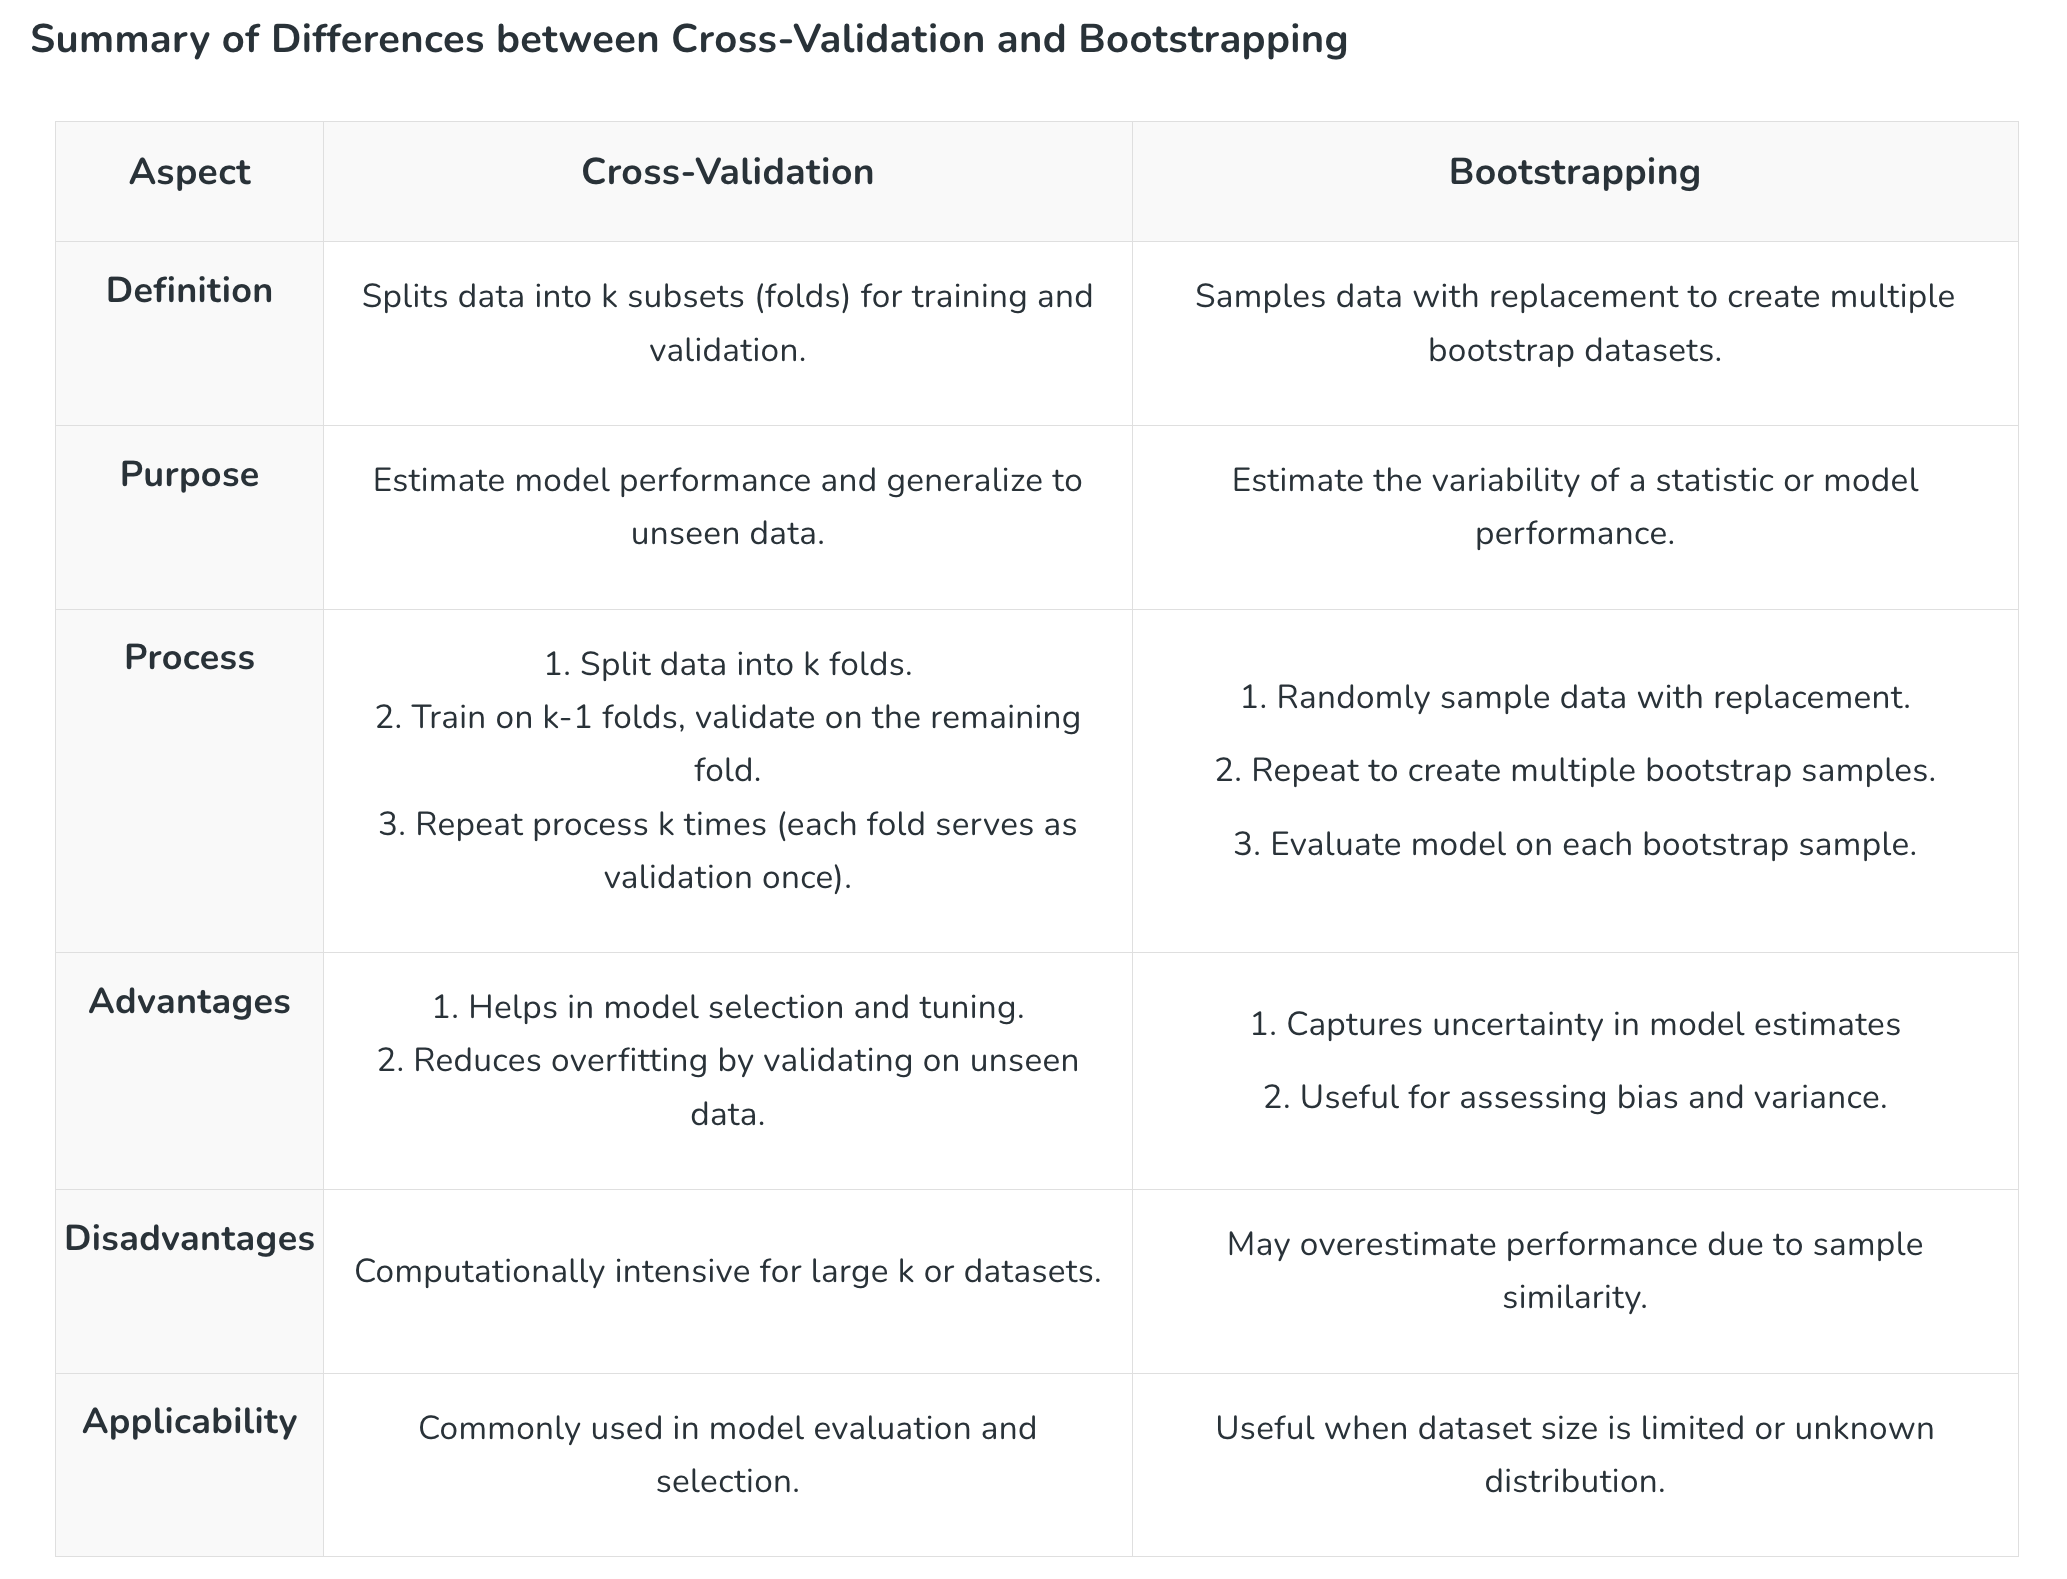

# Boosting 

**Boosting** is an **ensemble learning method** that combines multiple **weak learners** sequentially to create a **strong learner**.  

- A **weak learner** is a model that performs slightly better than random guessing (e.g., shallow decision tree, logistic regression).  
- Boosting focuses on **correcting the mistakes of previous models** in the sequence.  

---

## How Boosting Works (Step-by-Step)

1. Train the **first weak learner** on the data.  
2. Identify **misclassified or difficult samples**.  
3. Increase the **weights** of these difficult samples so the next model focuses on them.  
4. Train the **next weak learner** on the reweighted data.  
5. Repeat for **several iterations**.  
6. Combine predictions of all weak learners:
   - **Weighted voting** for classification  
   - **Weighted sum** for regression  

---

## Intuition

- Each subsequent model **tries to fix the errors** of the previous models.  
- The final model is **much stronger** than any individual weak learner.  

---

## Popular Boosting Algorithms

- **AdaBoost** – classic boosting using sample reweighting  
- **Gradient Boosting** – sequentially minimizes the loss using gradient descent  
- **XGBoost** – optimized, regularized gradient boosting  
- **LightGBM / CatBoost** – fast, scalable implementations with special handling for categorical features and large datasets  

---

## Key Points

- Boosting **reduces bias** and improves accuracy  
- Sensitive to **noisy data** (can overfit if data has many errors)  
- Works best with **weak learners** (shallow trees or small models)  
- Sequential nature makes it **slower to train** than bagging but often more accurate  

---

**One-sentence summary:**  
> Boosting builds a strong model by sequentially combining weak learners, focusing on the errors of previo



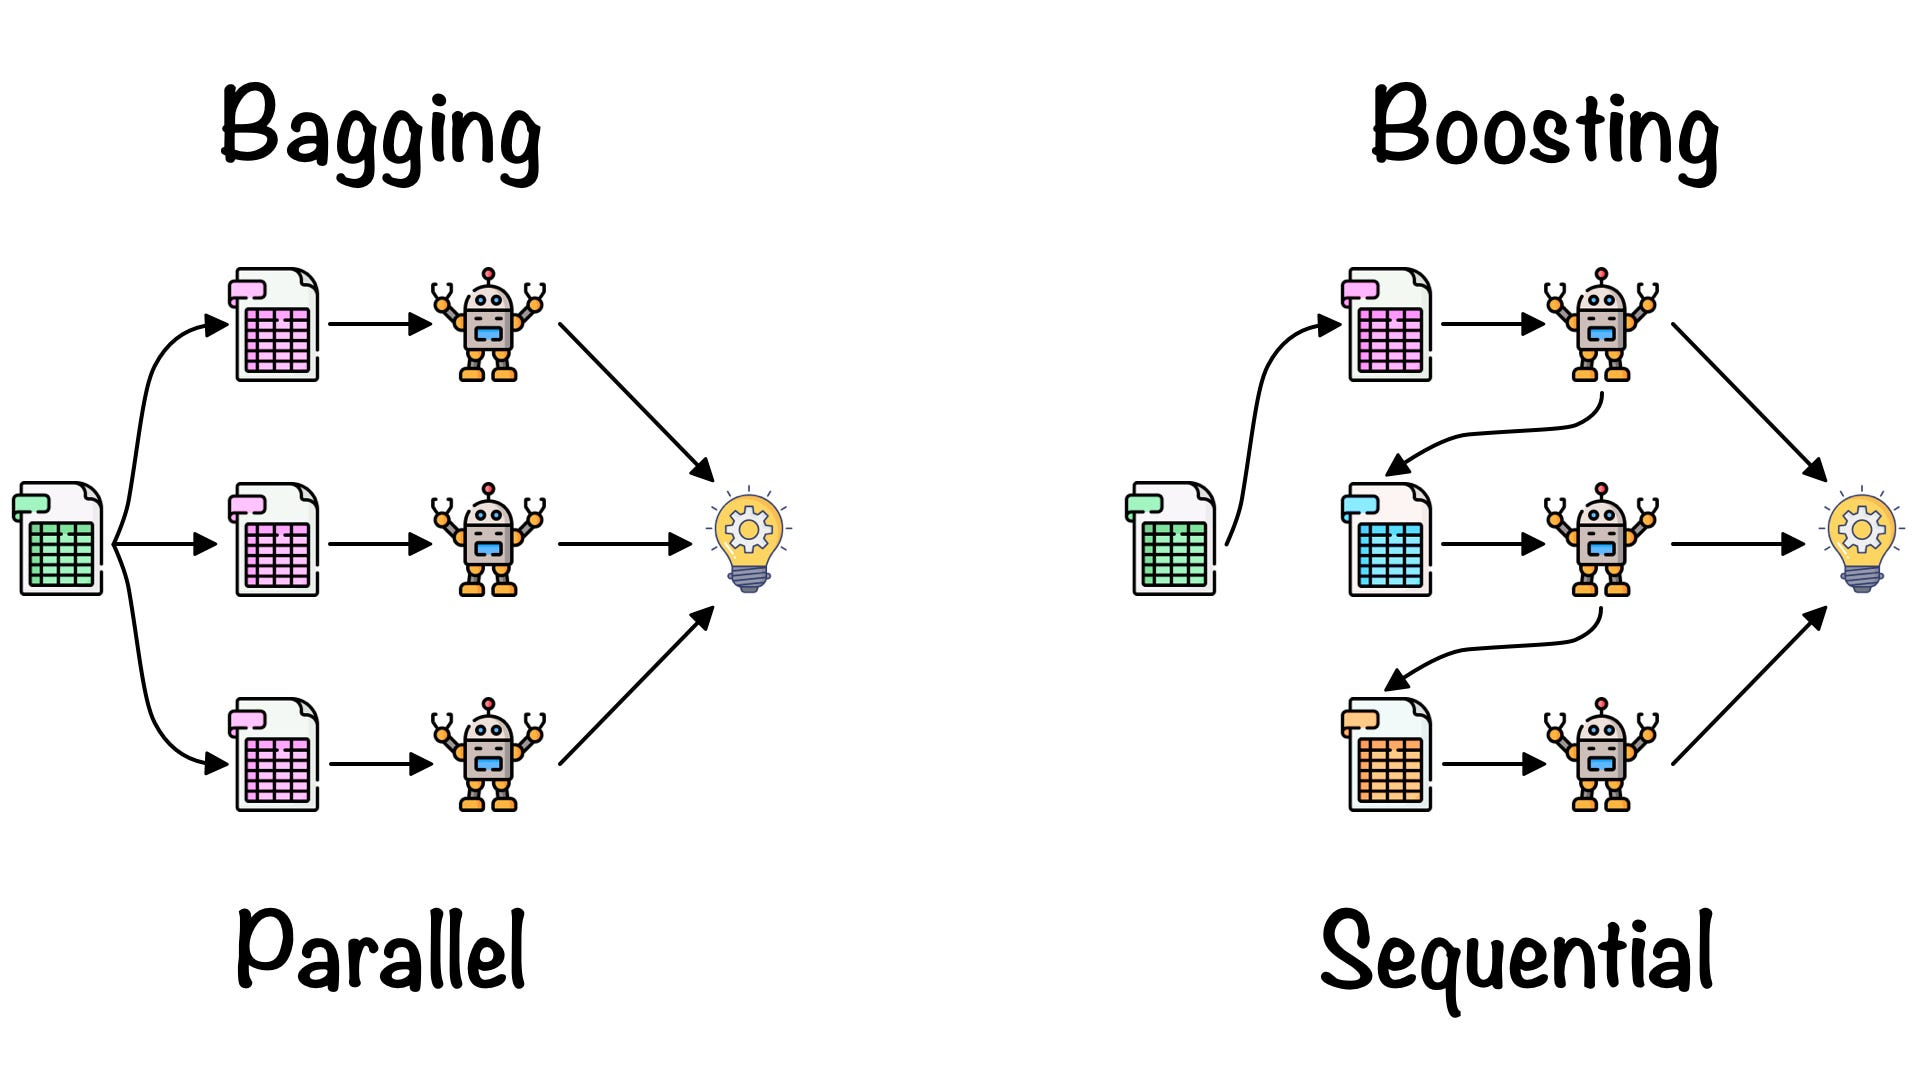


## Types of Boosting

- **AdaBoost**: adjusts the weights of each example to indicate which ones are more important for the next model.

- **GBM**: keeps the example weights constant but adjusts the predictions themselves, i.e., it decides how to “shift” predictions to reduce the error.

## Types of Boosting

| Library       | Features                                                                 | Main Advantages                                  |
|---------------|-------------------------------------------------------------------------|-------------------------------------------------|
| **XGBoost**   | Classic gradient boosting with L1/L2 regularization, tree-based learning, sparsity support | Fast, accurate, works well on a variety of datasets |
| **LightGBM**  | Uses **leaf-wise** tree growth (vs level-wise in standard GBM), **histogram-based** learning, optimized for large datasets | Extremely fast on large datasets, low memory usage |
| **CatBoost**  | Specializes in categorical features, uses **ordered boosting** to reduce gradient bias | Excels with categorical features, requires less preprocessing |



# Gradient Boosting (GBM)

1. **Train the first weak learner** on the dataset `(X, y)` → predictions `y_pred1`.

2. **Calculate residuals** (errors) for each example: 

`residuals1 = y_true - y_pred1`

3. Train the next weak learner (#2) on `(X, residuals1)` → predictions `y_pred2 = residuals1_pred`:
This model learns to correct the mistakes of the first model.

`residuals2 = residuals1 - y_pred2`

4. Train the next weak learner (#3) on `(X, residuals2)` → predictions `y_pred3 = residuals2_pred`:

`residuals3 = residuals2 - y_pred3`

5. Train the next weak learner (#4) on `(X, residuals3)` → predictions `y_pred4 = residuals3_pred`:

Final prediction is the sum of predictions from all weak learners:

`Final prediction = y_pred1 + y_pred2 + y_pred3`


# AdaBoost

https://www.youtube.com/watch?v=GM3CDQfQ4sw

1. Train the first model on `(X, y)` → predictions `y_pred1`.

2. Identify examples that were predicted worse than others.

3. Increase the weights of poorly predicted examples and decrease the weights of well-predicted ones.

4. Train the next model using the updated weights, so the next model focuses more on the hard examples.

5. Repeat this process N times, each time updating weights based on previous mistakes.
